# Product Performance Analysis
### Global Electronics Retailer — 2,492 SKUs across 8 Categories, 11 Brands

**Author:** _Your Name_
**Dataset:** [Global Electronics Retailer](https://mavenanalytics.io/data-playground/global-electronics-retailer) (Maven Analytics)

Module 3 of 4 (Sales Performance · Geographic Performance · **Product Performance** · Customer Segmentation). This module looks past total revenue to ask which categories, brands, and products are actually the healthiest — combining revenue, margin, and demand signals rather than ranking by size alone.


## 1. Research Questions

1. Which categories and brands lead on revenue — and do the same ones lead on margin?
2. Is the catalog too concentrated in a handful of SKUs?
3. Does color or price meaningfully predict how well a product sells?
4. Are any categories structurally declining rather than just dipping with the 2020 slowdown?


## 2. Methodology

Uses the same shared fact table (`src/data_prep.py`) as Modules 1-2. Product-level metrics are computed by grouping the fact table on `Product Name`, `Category`, `Brand`, and `Color`. For the price/quantity relationship (3.5) and the top-10 SKU list (3.2), we aggregate to one row per unique product to avoid a single high-volume SKU dominating a scatter plot meant to compare across products.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from data_prep import build_sales_fact_table
from viz_style import apply_style, COLORS, PALETTE, add_titles, add_source_note, money_formatter, pct_formatter

apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = build_sales_fact_table()
print(f"{df['Product Name'].nunique():,} products | {df['Category'].nunique()} categories | {df['Brand'].nunique()} brands | {df['Color'].nunique()} colors")

2,492 products | 8 categories | 11 brands | 16 colors


## 3. Findings

### 3.1 Category Revenue vs. Margin — Games and Toys Is a Double Weak Spot

Computers lead on revenue by a wide margin, but margin doesn't track revenue: Music/Movies/Audio Books has the *highest* margin (61%) despite modest revenue, while **Games and Toys has both the lowest revenue and the lowest margin (54.7%)** — a category with no redeeming metric.

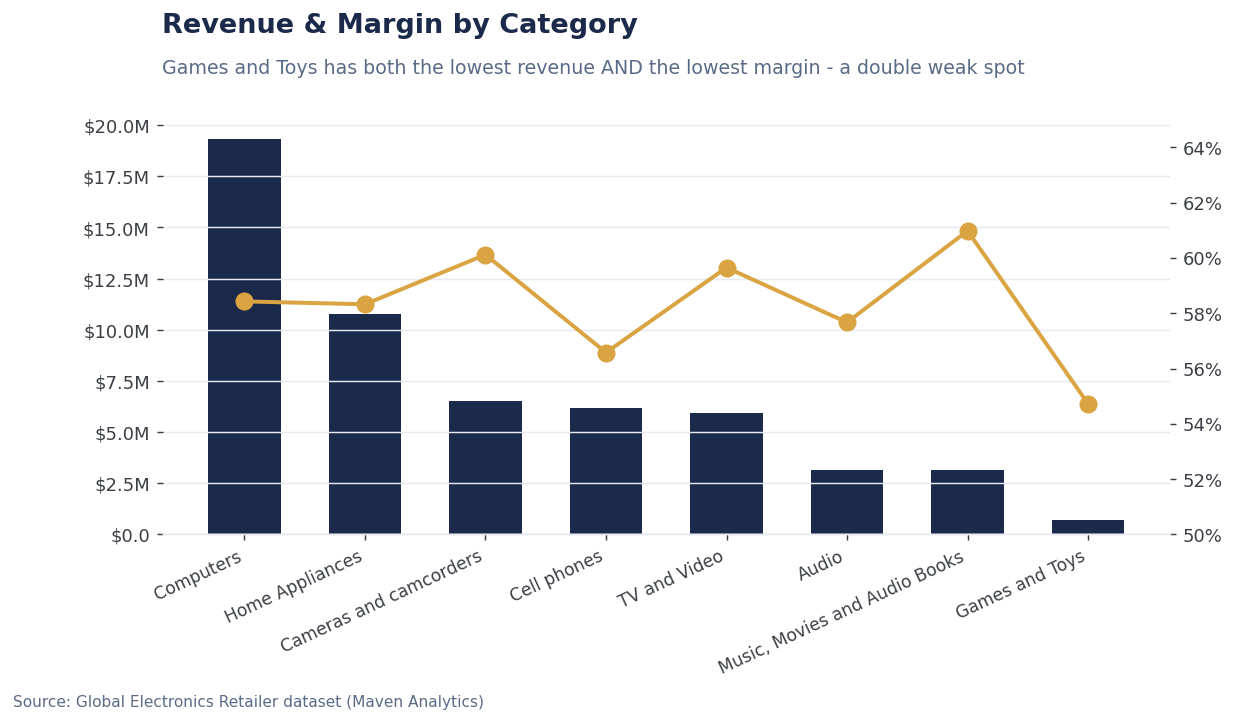

In [2]:
cat = df.groupby("Category").agg(Revenue=("Revenue_USD","sum"), Profit=("Profit_USD","sum")).sort_values("Revenue", ascending=False)
cat["Margin"] = cat["Profit"] / cat["Revenue"]

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.bar(cat.index, cat["Revenue"], color=COLORS["primary"], width=0.6)
ax1.yaxis.set_major_formatter(money_formatter())
ax2 = ax1.twinx()
ax2.plot(cat.index, cat["Margin"], color=COLORS["accent"], marker="o", markersize=9, linewidth=2.2)
ax2.set_ylim(0.50, 0.65)
ax2.yaxis.set_major_formatter(pct_formatter(0))
ax2.grid(False)
ax2.spines["top"].set_visible(False)
add_titles(ax1, "Revenue & Margin by Category", "Games and Toys has both the lowest revenue AND the lowest margin - a double weak spot")
ax1.set_xticks(range(len(cat.index)))
ax1.set_xticklabels(cat.index, rotation=25, ha="right", fontsize=9.5)
fig.subplots_adjust(bottom=0.22)
add_source_note(fig)
plt.savefig("../reports/figures/p01_category_revenue_margin.png")
plt.show()

### 3.2 Catalog Concentration — Heavy Reliance on One Product Line

**7 of the top 10 SKUs by revenue are the same two desktop PC models in different colors.** This is a concentration risk: a supply, pricing, or demand shock to desktop PCs would disproportionately hit total revenue.

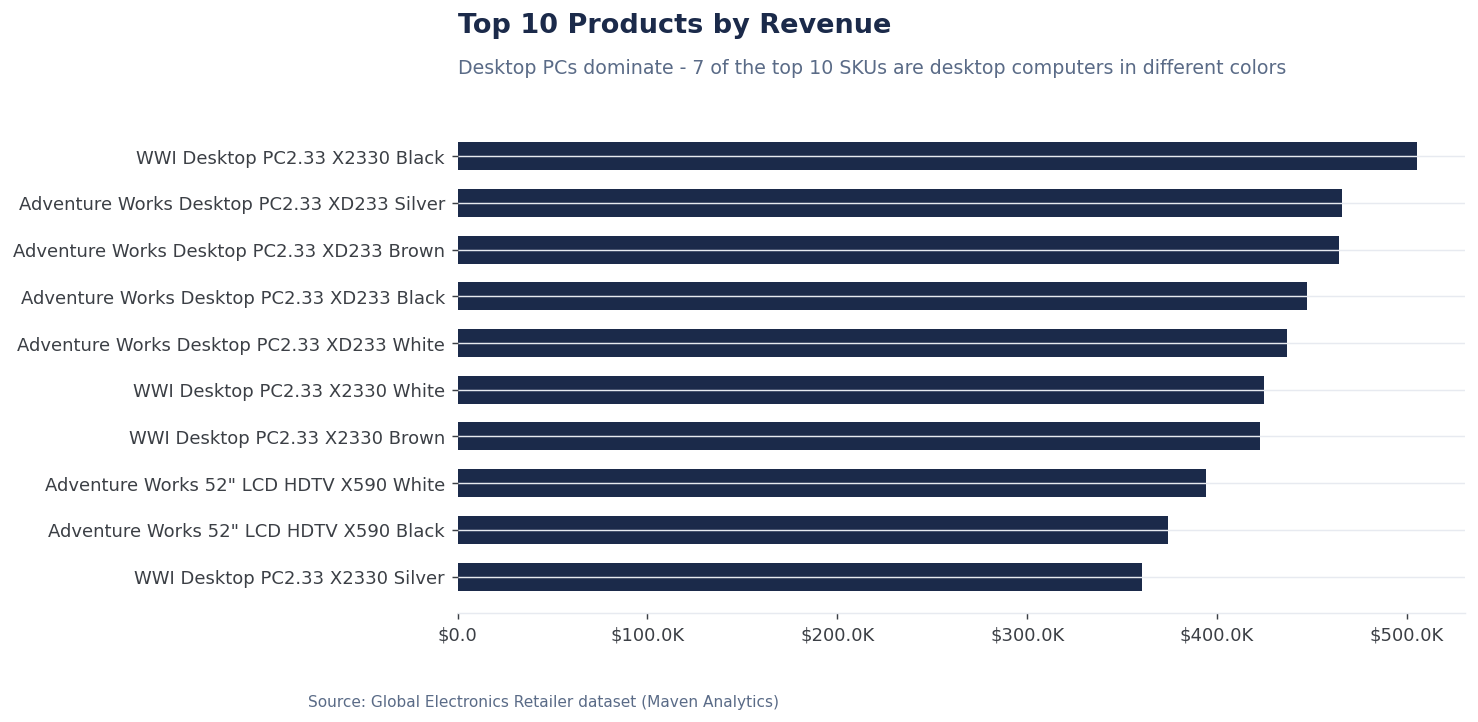

In [3]:
top10 = df.groupby("Product Name").agg(Revenue=("Revenue_USD","sum")).sort_values("Revenue", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(top10.index, top10["Revenue"], color=COLORS["primary"], height=0.6)
ax.xaxis.set_major_formatter(money_formatter())
add_titles(ax, "Top 10 Products by Revenue", "Desktop PCs dominate - 7 of the top 10 SKUs are desktop computers in different colors")
add_source_note(fig)
plt.savefig("../reports/figures/p02_top10_products.png")
plt.show()

### 3.3 Brand Performance

Fabrikam and Proseware post above-average margins (~60%) despite mid-tier revenue — worth studying for what they're doing differently. **Tailspin Toys (54.6%) and The Phone Company (56.8%) are the two lowest-margin brands**, both notably below the ~58.6% company average.

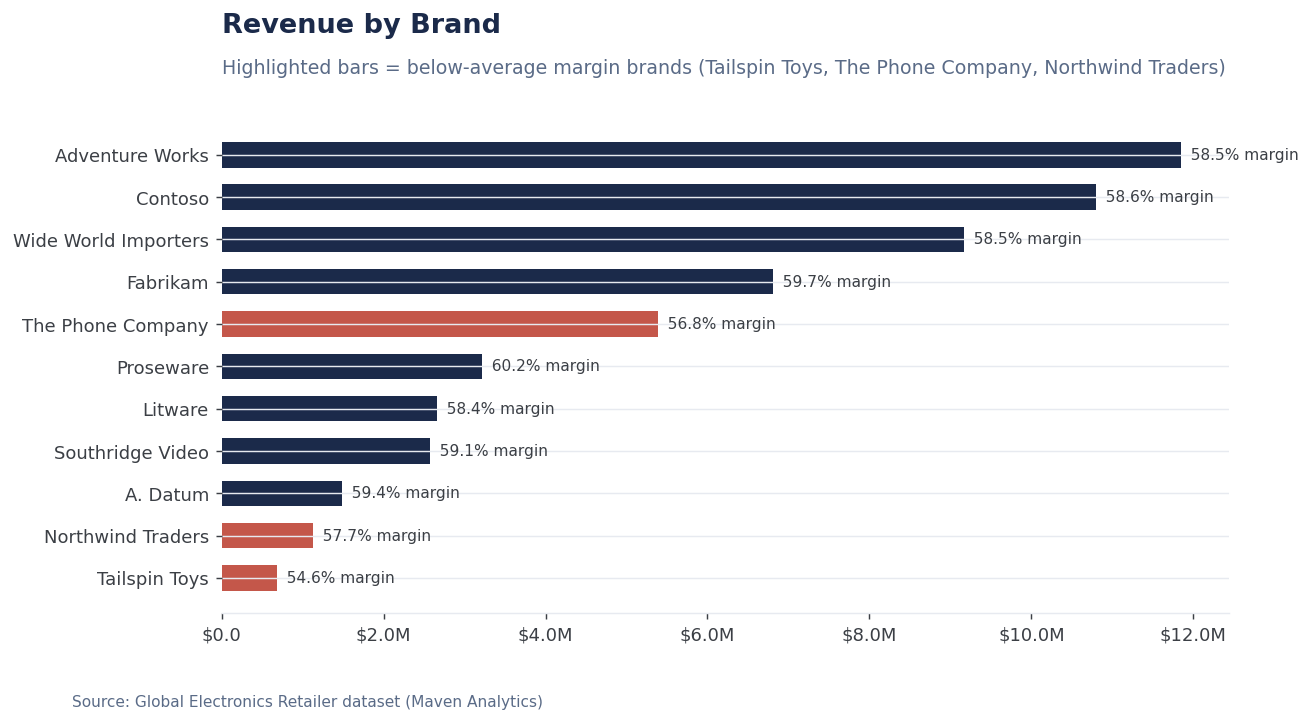

In [4]:
brand = df.groupby("Brand").agg(Revenue=("Revenue_USD","sum"), Profit=("Profit_USD","sum")).sort_values("Revenue", ascending=True)
brand["Margin"] = brand["Profit"] / brand["Revenue"]

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = [COLORS["negative"] if m < 0.58 else COLORS["primary"] for m in brand["Margin"]]
ax.barh(brand.index, brand["Revenue"], color=colors, height=0.6)
ax.xaxis.set_major_formatter(money_formatter())
add_titles(ax, "Revenue by Brand", "Highlighted bars = below-average margin brands (Tailspin Toys, The Phone Company, Northwind Traders)")
for i, (v, m) in enumerate(zip(brand["Revenue"], brand["Margin"])):
    ax.text(v, i, f"  {m*100:.1f}% margin", va="center", fontsize=8.5, color=COLORS["text"])
add_source_note(fig)
plt.savefig("../reports/figures/p03_brand_performance.png")
plt.show()

### 3.4 Color Preference Is Heavily Skewed to Neutrals

Black, White, and Silver together make up roughly two-thirds of all product revenue. Any new-SKU or inventory-planning decision should default to these three finishes unless there's a specific reason to diversify.

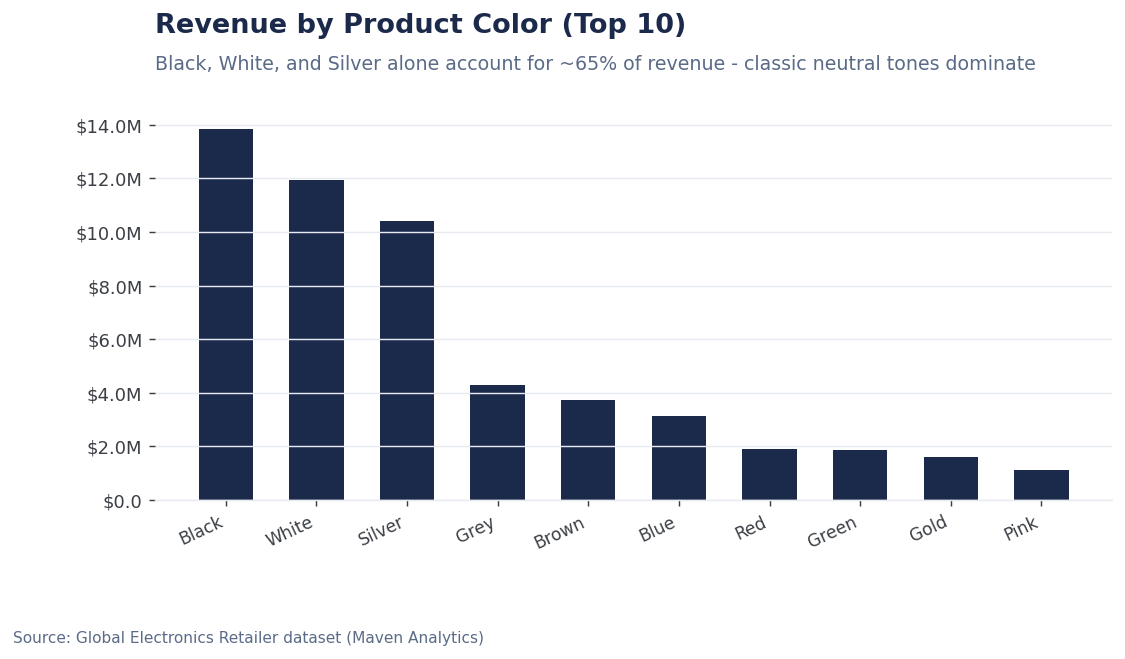

Black + White + Silver share of total revenue: 64.9%


In [5]:
color = df.groupby("Color").agg(Revenue=("Revenue_USD","sum")).sort_values("Revenue", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.bar(color.index, color["Revenue"], color=COLORS["primary"], width=0.6)
ax.yaxis.set_major_formatter(money_formatter())
add_titles(ax, "Revenue by Product Color (Top 10)", "Black, White, and Silver alone account for ~65% of revenue - classic neutral tones dominate")
ax.set_xticks(range(len(color.index)))
ax.set_xticklabels(color.index, rotation=25, ha="right", fontsize=9.5)
fig.subplots_adjust(bottom=0.20)
add_source_note(fig)
plt.savefig("../reports/figures/p04_revenue_by_color.png")
plt.show()

top3_share = color.head(3)["Revenue"].sum() / df["Revenue_USD"].sum()
print(f"Black + White + Silver share of total revenue: {top3_share*100:.1f}%")

### 3.5 Price Doesn't Strongly Predict Volume

Across products, price and units sold are only weakly negatively correlated (r=-0.13). High unit counts appear at both very low prices (accessories, cables) and mid/high prices (some computers) — category and product type matter more than price point alone for driving volume.

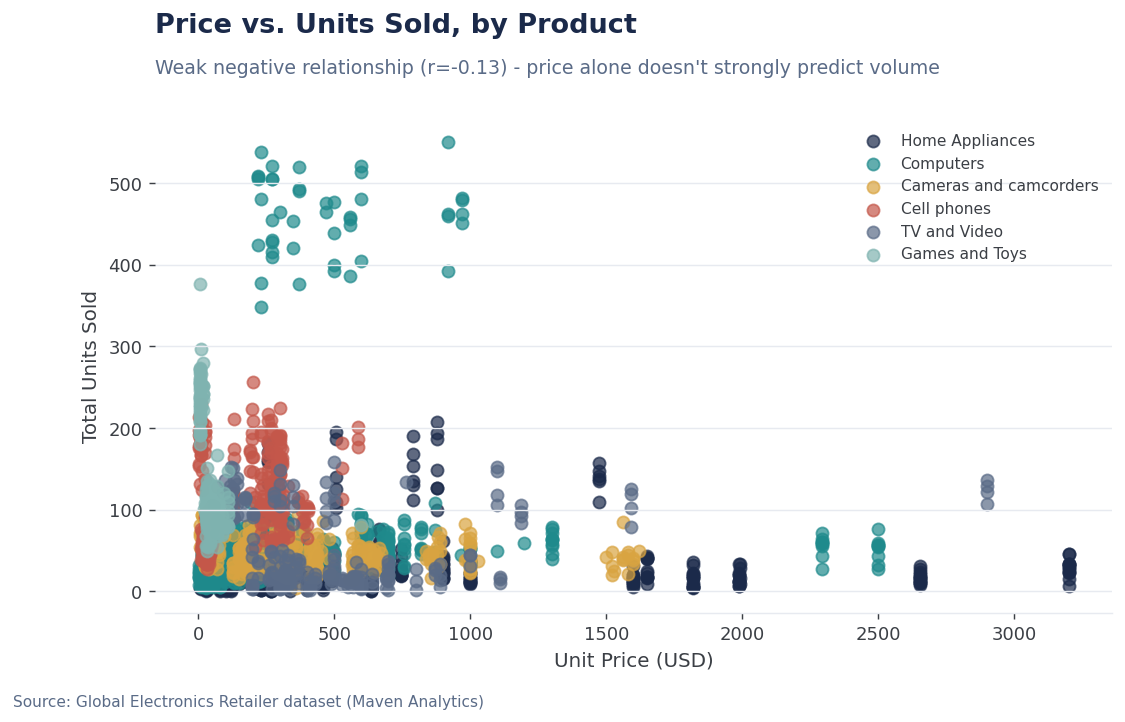

In [6]:
prod_level = df.groupby("Product Name").agg(Price=("Unit Price USD","first"), Qty=("Quantity","sum"), Category=("Category","first"))
cats_top = prod_level["Category"].value_counts().head(6).index.tolist()

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, c in enumerate(cats_top):
    sub = prod_level[prod_level["Category"] == c]
    ax.scatter(sub["Price"], sub["Qty"], s=45, alpha=0.7, color=PALETTE[i % len(PALETTE)], label=c)
ax.set_xlabel("Unit Price (USD)")
ax.set_ylabel("Total Units Sold")
corr = prod_level["Price"].corr(prod_level["Qty"])
add_titles(ax, "Price vs. Units Sold, by Product", f"Weak negative relationship (r={corr:.2f}) - price alone doesn't strongly predict volume")
ax.legend(loc="upper right", fontsize=8.5)
add_source_note(fig)
plt.savefig("../reports/figures/p05_price_vs_quantity.png")
plt.show()

### 3.6 Home Appliances Is Structurally Declining, Not Just COVID-Affected

Every other top category grew through 2019 before the 2020 pullback (see Module 1). **Home Appliances is the exception** — it already peaked in 2018 and was declining in 2019, *before* COVID. This points to a category-specific issue (assortment, competition, saturation) rather than the macro effect that hit everything else in 2020.

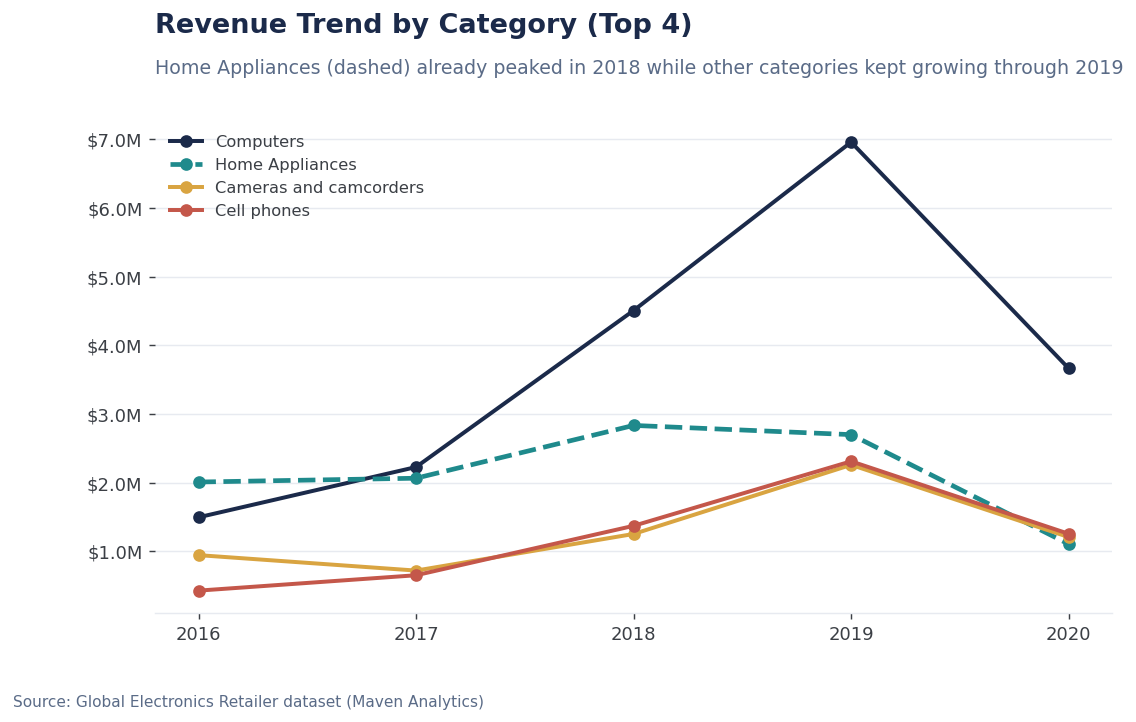

In [7]:
full = df[df["Order_Year"].between(2016, 2020)]
top_cats = full.groupby("Category")["Revenue_USD"].sum().sort_values(ascending=False).head(4).index.tolist()
piv = full[full["Category"].isin(top_cats)].groupby(["Order_Year","Category"])["Revenue_USD"].sum().unstack()

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, c in enumerate(top_cats):
    style = "--" if c == "Home Appliances" else "-"
    lw = 2.6 if c == "Home Appliances" else 2.2
    ax.plot(piv.index.astype(str), piv[c], marker="o", linewidth=lw, linestyle=style, color=PALETTE[i], label=c)
ax.yaxis.set_major_formatter(money_formatter())
add_titles(ax, "Revenue Trend by Category (Top 4)", "Home Appliances (dashed) already peaked in 2018 while other categories kept growing through 2019")
ax.legend(loc="upper left", fontsize=9)
add_source_note(fig)
plt.savefig("../reports/figures/p06_category_trend.png")
plt.show()

## 4. Business Conclusions & Recommendations

1. **Cut or reposition Games and Toys.** It's the only category weak on both revenue and margin, with no clear strength to build on — a strong candidate for either a focused turnaround (better assortment, bundling) or portfolio reduction.

2. **De-risk the desktop-PC concentration.** With 7 of the top 10 SKUs from one product line, any supply/demand shock there hits total revenue hard. Diversifying the hero-SKU list (e.g., promoting the strong-margin Fabrikam/Proseware lines) reduces this single point of failure.

3. **Investigate Tailspin Toys and The Phone Company's below-average margins** — whether it's cost structure, discounting, or return rates, these two brands are the clearest margin-improvement opportunity in the catalog.

4. **Default new SKUs and inventory buys to Black/White/Silver** unless there's a specific market signal to diversify — chasing color variety beyond neutrals is chasing a small share of revenue.

5. **Treat Home Appliances as a strategic review, not a pandemic casualty.** Because its decline started in 2019, before COVID, recovery plans built around "waiting for demand to bounce back" (as worked for other categories) likely won't work here — it needs its own assortment/competitive review.
